<h1><b>
IAU_B Semester project
</b></h1>

<h3>
Objective:
Predict oxygen saturation variable - <b>oximetry</b>
</h3>

# Import Statements

In [1]:
import matplotlib.pyplot as plt
from datetime import datetime
import scipy.stats as stats
import pingouin as pg
import seaborn as sns
import pandas as pd
import scipy
import re
import numpy as np
import statsmodels.api as sm

# Function definitions

In [2]:
def unify_formats(dataframe, col_name):
    df_cpy = dataframe.copy(deep = True)
    format_d = {1 : "%m/%d/%Y", 2 : "%m/%d/%Y, %H:%M:%S", 3 : "%d %b %Y", 4 : "%Y-%m-%d", 5 : "%Y/%m/%d"}
    col_ind = list(df_cpy.columns).index(col_name)
    for date_row in range(len(df_cpy[col_name])):
        date_str = df_cpy.iat[date_row, col_ind]
        parsed_str = ""
        for i in range(1, len(format_d) + 1):
            try:
                parsed_str = datetime.strptime(date_str, format_d[i])
            except ValueError:
                continue
            except Exception:
                pass
            break
        if (type(parsed_str) != str):
            df_cpy.iat[date_row, col_ind] = parsed_str.strftime("%Y-%m-%d")
        else:
            df_cpy.iat[date_row, col_ind] = date_str
            
    return df_cpy
        

In [3]:
def detect_outliers(dataframe, column_name):
    col_series = dataframe[column_name]
    anom_mask = None
    
    bb_IQR = col_series.quantile(0.25) - 1.5 * stats.iqr(col_series) #boundary for values that are less than 1.5 IQR from 25th percentile 
    tb_IQR=  col_series.quantile(0.75) + 1.5 * stats.iqr(col_series) #boundary for values that are more than 1.5 IQR from 75th percentile 
    bb_3SD = col_series.mean() - (col_series.std() * 3) #boundary for values that are less than 3 standard deviations
    tb_3SD= col_series.mean() + (col_series.std() * 3) #boundary for values that are more than 3 standard deviations
    
    anom_mask = (dataframe[column_name] > tb_IQR) | (dataframe[column_name] < bb_IQR)
    anom_mask = ((dataframe[column_name] > tb_3SD) | (dataframe[column_name] < bb_3SD)) | anom_mask
    print(anom_mask.sum())
    
    return anom_mask
    

In [4]:
def remove_outliers(dataframe, mask, inplace):
    df_copy = None
    labels = [list(mask).index(row) for row in list(mask)if row]
    if (inplace):
        dataframe.drop(labels, axis = 0, inplace = True)
    else:
        df_copy = dataframe.drop(labels, axis = 0, inplace = False)
    
    return None if inplace else df_copy

In [5]:
def replace_outliers(dataframe, mask, column_name, method, inplace):
    df_median = dataframe[column_name].median()
    df_copy = dataframe.copy()
    
    if(method == "capping"):
        cond_more = (dataframe[column_name] > df_median) & mask
        cond_less = (dataframe[column_name] < df_median) & mask
        
        
        if (inplace):
            dataframe[column_name].mask(cond_less, other = dataframe[column_name].quantile(0.05), inplace = True)
            dataframe[column_name].mask(cond_more, other = dataframe[column_name].quantile(0.95), inplace = True)
        else:
            df_copy[column_name] = df_copy[column_name].mask(cond_less, other = dataframe[column_name].quantile(0.05), inplace = False)
            df_copy[column_name] = df_copy[column_name].mask(cond_more, other = dataframe[column_name].quantile(0.95), inplace = False)
            
    elif(method == "median_v"):
        if (inplace):
            dataframe[column_name].mask(mask, other = df_median, inplace = True)
        else:
            df_copy[column_name] = dataframe[column_name].mask(mask, df_median, inplace = False)
        
        
    if not inplace:
        return df_copy
    else:
        return None
        

In [6]:
# dataframe.index returns a Series type attribute of dataframe (a Series of all index names)
#dataframe.columns returns a Series type attribute of dataframe (a Series of all column names)

# any(axis = 0/1) - returns true if iterable has at least one element in that iterable with value of true
# sum(axis = 0/1) - returns number of true values in an array

#to create an empty column use empty Series - "" and index series of the current dataset 

# set_index - make a series of data, typically column an index 
# reset_index - remove the current index and make it a column, works for MultiDimentional indices
#stack uses both indices and columns of the current dataframe to make from both of them indices
# unstack - lets you create a table entirely from columns. One column is going to be an index 
# another is going to be a column, and other are gonna be values. Just need to look at it from left to right.
#      c1 c2 c3 c4 c5...
# ind1 v1 t1 vv1 vv2 vv3...
# ind2 v2 t2 vv7 vv8 vv9...
# ind3 v3 t3 vv11 vv15 vv18...
# ind4 v4 t4 vv12 vv4 vv5...
# ind5 v5 t5 vv20 vv6 vv19...

# c1 - column 1
# c2 - column 2
# ...
# ind1 - index 1
# ind2 - index 2
# ...

# v1, t1, vvk - values of the dataframe, k is (1 - 50)

# c1 will become index
# c2 will become column
# and all other will become their values

# So: v1 - index; t1 - column; vv1 - value
# So: v1 - index; t2 - column; vv2 - value
# So: v1 - index; t3 - column; vv3 - value
# and so on

# pivot works similarly
# but there you can explicitly set "index" column and "column" column 

# dataframe.groupby("column").aggregate("sum") - sums values of each column's group if possible

# columns can be selected using dataframe.rename(columns = {"old_name": "new_name", ...})

# isnull(), alias for isna() returns the same sized array of boolean values, at each position indicating true or false, correspodingly Nan, None, np.nan value or not

# dataframe[dataframe['column_name'].isnull()] - selection of rows where there are empty values

#notnull() is alias for notna() is a function that returns for a Series of data the same sized array wih boolean values denoting whether value is true or not

# dataframe.iloc[:, 0:65:3] - is purely integer based function to retrieve values out of a datset
# dataframe.iloc[23, 43] - retrive a singular value out of a dataframe

# dataframe.loc[["row_ind1", "row_ind2", "row_ind3"], ["col1", "col2", "col3"]] - get a subslice of rows and columns using purely labels
# dataframe.loc["col1", "col2"] - get certain columns
# dataframe.loc[["ind1", "ind2"]] - get certain rows

# dataframe.at[3, "col"] - get a value by specifying row-column pair
# dataframe.at[3, "col"] = 34 - set a value inside of a cell 

# dataframe.iat[2, 54] - purely integer based search at a specific position
# dataframe.loc[6].iat[23] - get a value at a specific position within a series

# Rudimentary file content analysis

<h4>
File "patient.csv" has a corrupted structure, due to that fact it will be reformatted for further examination
</h4>

In [7]:
observations = pd.read_csv("Datasets/observation.csv", sep = '\t')
stations = pd.read_csv("Datasets/station.csv", sep = '\t')

In [8]:
stations.columns

Index(['QoS', 'longitude', 'station', 'latitude', 'code', 'revision'], dtype='object')

In [9]:
stations.shape

(744, 6)

In [10]:
stations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   QoS        744 non-null    object 
 1   longitude  744 non-null    float64
 2   station    744 non-null    object 
 3   latitude   744 non-null    float64
 4   code       744 non-null    object 
 5   revision   744 non-null    object 
dtypes: float64(2), object(4)
memory usage: 35.0+ KB


In [11]:
stations.head(10)

,QoS,longitude,station,latitude,code,revision
0,good,-99.32556,San Lorenzo Acopilco,19.32889,MX,"09/18/2025, 00:00:00"
1,good,59.48390,Kachkanar,58.70020,RU,2024/07/01
2,good,15.00913,Misterbianco,37.51803,IT,27 Apr 2019
3,maintenance,-91.11667,Chichicastenango,14.93333,GT,2025/01/08
4,excellent,138.31667,Suzaka,36.65000,JP,"08/02/2017, 00:00:00"
5,good,2.59753,Tchaourou,8.88649,BJ,2024/07/28
6,excellent,-91.06177,Greenville,33.41012,US,2019/03/23
7,excellent,0.93333,East Dereham,52.68333,GB,10 Jun 2021
8,good,-68.30000,Ushuaia,-54.80000,AR,18 Dec 2016
9,good,15.28318,Brazzaville,-4.26613,CG,"03/04/2024, 00:00:00"


In [12]:
stations.describe()

,longitude,latitude
count,744.000000,744.000000
mean,8.626584,30.003726
std,74.236557,22.522047
min,-123.026210,-54.800000
25%,-69.364370,15.734440
50%,8.994565,37.277680
75%,71.235350,47.050000
max,178.004170,68.798330


<h5>
<b>Revision</b> column manifests the exact time when a station was revisioned for its condition in each record.<br>
<p>
Each patient has paid a visit and was examined during an arbitrary time, <b>registration</b> column in <b>patients</b> dataframe. And the time of patient's visit can denote the station's condition at that time, since we have a <b>stations</b> dataframe with all revision records. And after the visit data that were extracted from devices reading patient's statistics were saved into <b>observations </b>dataset.
<p>
If we assume the conjecture that during visiting time of each patient state of the station was the closest earliest known state in <b>stations</b> dataframe, we can acquire state of the station at that moment in time, and therefore connect <b>stations</b> and <b>patients</b> dataframes in that way.
</h5>

In [13]:
stations.station.nunique() == stations.station.count()

np.False_

<h5>
Rows in <b>stations</b> dataframe can be grouped based on the <b>station</b> and <b>QoS</b> columns: each unique station name can be taken as an anchor towards which QoS records are gathered. 
<p>Afterwards average of all the records of every unique station's group regarding <b>QoS</b> column can be taken. <small><small><small>(Since we don't know whether we can merge <b>patients</b> dataframe with the rest of dataframes, this is considered a possibility)</small></small></small>
<p>
Before averaging QoS values, all categorical ordinal values must be mapped onto numbers.
</h5>

In [14]:
stations.drop(["QoS", "revision"], axis = 1).nunique()

longitude    522
station      523
latitude     523
code          98
dtype: int64

In [15]:
stations.QoS.unique()

array(['good', 'maintenance', 'excellent', 'acceptable'], dtype=object)

QoS unique values' mappings:<br>
maintenance - 0<br>
acceptable - 1<br>
good - 2<br>
excellent - 3

In [16]:
stations["QoS"] = stations["QoS"].map({"maintenance" : 0, "acceptable" : 1, "good" : 2, "excellent" : 3})

In [17]:
file = open("Datasets/patient.csv", "r", encoding="utf-8")
parsed_file = open("Datasets/patient_redacted.csv", "w")

columns = ["registration", "latitude", "longitude", "birthdate", "ssn", "mail", "blood_group", "station_ID", "user_id"]
parsed_file.write(";".join(columns) + "\n")
new_lines = list()
lines = file.readlines()
del lines[0]

line_ctr = -1
for line in lines:
    if (line[0].isspace()):
        new_lines.append(line.strip() + "\n")
        line_ctr += 1
    else:
        new_lines[line_ctr] = new_lines[line_ctr].strip() + " " + line

del lines

for index in range(line_ctr):
    nc_line = new_lines[index]
    user_id = re.findall("\s+\d{4}\s+", nc_line)
    location = re.findall("\(Decimal\('.*?'\),\sDecimal\('.*?'\)\)", nc_line)
    ssn = re.findall("(?:[A-Z0-9]{16}|\d{3}-\d{2}-\d{4}|\d{11})", nc_line)
    mail = re.findall("[\d\w.]+@[\d\w.]+", nc_line)
    blood_group = re.findall("[ABO]{1,2}[+-]", nc_line)
    station_ID = re.findall("\d{1,3}\n", nc_line)
    dates = re.findall("((?:^|\s+?)(?:\d{4}[./-]\d{2}[./-]\d{2}|\d{2} \w{3} \d{4}|(?:\d{2}/){2}\d{4}(?:,\s(?:\d{2}:){2}\d{2})?)\s+?)", nc_line)

    
    #\s*(?:\d{4}[./-]\d{2}[./-]\d{2}|\d{2} \w{3} \d{4}|(?:\d{2}/){2}\d{4}(?:,\s(?:\d{2}:){2}\d{2})?)\s - older version for whole
    loc_pos = re.search("\(Decimal\('.*?'\),\sDecimal\('.*?'\)\)", nc_line)
    date_pos = re.search("((?:^|\s+?)(?:\d{4}[./-]\d{2}[./-]\d{2}|\d{2} \w{3} \d{4}|(?:\d{2}/){2}\d{4}(?:,\s(?:\d{2}:){2}\d{2})?)\s+?)", nc_line)
    ssn_pos = re.search("([A-Z0-9]{16})|(\d{3}-\d{2}-\d{4})|(\d{11})", nc_line)
    user_id_pos = re.search("\s+\d{4}\s+", nc_line)
    
    longitude = None
    latitude = None
    
    if(loc_pos == None):
        location = None
    else:
        location = re.match("\(Decimal\('(?P<latitude>.*?)'\),\sDecimal\('(?P<longitude>.*?)'\)\)", location[0])
        longitude = location["longitude"]
        latitude = location["latitude"]
    
    ssn = None if(ssn_pos == None) else ssn[0]
    mail = None if(len(mail) == 0) else mail[0]
    blood_group = None if(len(blood_group) == 0) else blood_group[0]
    station_ID = None if(len(station_ID) == 0) else station_ID[0].strip()
    
    if(len(dates) > 1):
        registration = dates[0].strip()
        birthdate = dates[1].strip()
    elif(date_pos != None):
        if(re.match("((?:^|\s+?)(?:\d{4}/\d{2}/\d{2}|\d{2} \w{3} \d{4}|(?:\d{2}/){2}\d{4}(?:,\s(?:\d{2}:){2}\d{2})?)\s+?)", dates[0]) != None):
            registration = dates[0].strip()
            birthdate = None
        elif(location != None):
            if(date_pos.start() < loc_pos.start()):
                registration = dates[0].strip()
                birthdate = None
            else:
                birthdate = dates[0].strip()
                registration = None
    else:
        registration = None
        birthdate = None
        
   
    # print(f"<{registration};{latitude};{longitude};{birthdate};{ssn};{mail};{blood_group};{station_ID}> - line")
    parsed_file.write(f"{registration};{latitude};{longitude};{birthdate};{ssn};{mail};{blood_group};{station_ID}\n")

    
    

In [18]:
patients = pd.read_csv("Datasets/patient_redacted.csv", sep = ";")
patients = unify_formats(patients, "registration")
patients.to_csv("Datasets/patient_redacted.csv", index = False, sep = ";")



In [19]:
patients.head(10)

,registration,latitude,longitude,birthdate,ssn,mail,blood_group,station_ID,user_id
0,2020-09-28,-80.004689,37.669680,1966-05-04,TGLMTT84A52G804H,isabella08@tiscali.it,AB-,316,NaN
1,2019-12-04,50.103476,150.889543,NaN,TMBLVR61M27C821K,mirko95@vodafone.it,A+,482,NaN
2,2020-12-06,68.767255,-51.583432,NaN,323-46-6887,roemertassilo@googlemail.com,B-,510,NaN
3,2021-06-21,80.373267,-64.664433,NaN,319-42-4326,jopichlaszlo@gmx.de,AB-,398,NaN
4,2019-07-23,-48.825258,-43.424063,1916-05-23,38719056400,procha@bol.com.br,A-,432,NaN
5,2021-02-23,80.870888,12.809605,1968-01-31,227-33-1143,ryoheitakahashi@gmail.com,B-,311,NaN
6,2022-11-17,49.116681,-118.159852,1967-03-01,417-85-5093,kumiko46@yahoo.com,O-,624,NaN
7,2023-10-29,-59.856178,161.027118,NaN,330-87-2812,zsullivan@hotmail.com,B+,183,NaN
8,2021-07-22,27.072803,77.058447,1967-03-26,76590214352,manuellasouza@yahoo.com.br,O-,152,NaN
9,2025-09-13,-43.823200,136.379925,1967-10-12,TMBCRT91T30G494Y,giampaolomerisi@hotmail.it,B+,611,NaN


In [20]:
patients.shape

(1993, 9)

In [21]:
patients.columns

Index(['registration', 'latitude', 'longitude', 'birthdate', 'ssn', 'mail',
       'blood_group', 'station_ID', 'user_id'],
      dtype='object')

In [22]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1993 entries, 0 to 1992
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   registration  1993 non-null   object 
 1   latitude      1895 non-null   float64
 2   longitude     1895 non-null   float64
 3   birthdate     1121 non-null   object 
 4   ssn           1993 non-null   object 
 5   mail          1993 non-null   object 
 6   blood_group   1993 non-null   object 
 7   station_ID    1993 non-null   int64  
 8   user_id       0 non-null      float64
dtypes: float64(3), int64(1), object(5)
memory usage: 140.3+ KB


In [23]:
patients.describe()

,latitude,longitude,station_ID,user_id
count,1895.000000,1895.000000,1993.000000,0.0
mean,0.593081,-5.020118,374.513798,NaN
std,51.766906,105.138737,211.473787,NaN
min,-89.955009,-179.992511,0.000000,NaN
25%,-43.791338,-94.108929,202.000000,NaN
50%,0.263759,-7.612571,369.000000,NaN
75%,44.979314,84.628562,556.000000,NaN
max,89.842271,179.495013,743.000000,NaN


In [24]:
patients.station_ID.nunique()

692

In [25]:
print(patients["registration"].min())
print(patients["registration"].max())

2018-09-24
2025-09-22


In [26]:
patients["longitude"].isnull().any().sum()

np.int64(1)

<h4>
Since number of unique stations in station_ID field is different and even more that number of unique records of stations in <b>stations</b> dataframe, the merge operation between <b>stations</b> and <b>patients</b> dataframe is practically impossible.
Not enough information is provided to merge them both together, since for merging process a column with stations' IDs would be required inside of the <b>stations</b> datafame.<br> On station_ID column, where for each record in <b>patients</b> dataframe, station_ID column with a particular record in <b>stations</b> dataframe would be needed as well as met condition, that record in <b>stations</b> dataframe would be chosen if revision time of the station would be the closest revision time prior to registration time of the patient.
</h4>

<h4>
Using <b>longitude</b> and <b>latitude</b> columns both <b>observations</b> and <b>stations</b> dataframes can be merged into one dataframe <b>main_df</b>. Of course if we have all unique records in <b>stations</b> dataframe. But due to the fact that we don't have all unique records in the stations dataframe, and we can't quite figure out when each observation record took place, we can't merge those 2 files. Only if we drop revision column and somehow determine for each station QoS value, we would be able to merge those files.
<br><br>
There would be 2 to 3 times more of rows, but most of them would be redundant. Each row would have a couple of copies of it, and each copy would have it's own time of station's revision, which is unfortunately rendered useless.
</h4>

# Attribute Selection and elementary description

<h4>
SpO₂ - Peripheral oxygen saturation | (95–100%)<br>
HR - Heart rate from pulse oximeter | (60–100 bpm)<br>
PI - Perfusion index | (0.2–20%)<br>
RR - Respiratory rate | (12–20 breaths/min)<br>
EtCO₂ - End-tidal carbon dioxide | (35–45 mmHg)<br>
FiO₂ - Fraction of inspired oxygen | (21–100%)<br>
PRV - Pulse rate variability | (20–200 ms)<br>
BP - Blood pressure (systolic diastolic mean) | (90/60–120/80 mmHg)<br>
Skin Temperature - Peripheral temperature | (33–38 °C)<br>
Motion/Activity index - Sensor artifact correction | (Relative units)<br>
PVI - Pleth Variability Index | (10–20%)<br>
Hb level - Hemoglobin concentration | (12–18 g/dL)<br>
SV - Stroke volume | (60–100 mL/beat)<br>
CO - Cardiac output | (4–8 L/min)<br>
Blood Flow Index - Optical/near-infrared blood flow measurement | (Relative units)<br>
PPG waveform features - Photoplethysmography signal parameters | (Relative units)<br>
Signal Quality Index - Reliability indicator of readings | (0–100)<br>
Respiratory effort - Chest impedance or belt-derived effort | (Relative units)<br>
O₂ extraction ratio - Calculated oxygen extraction metric | (0.2–0.3)<br>
SNR - Signal-to-noise ratio from sensor | (20–40 dB)<br>
</h4>


In [27]:
b_value = 696

In [28]:
observations.shape

(12135, 23)

In [29]:
observations.columns

Index(['SpO₂', 'HR', 'PI', 'RR', 'EtCO₂', 'FiO₂', 'PRV', 'BP',
       'Skin Temperature', 'Motion/Activity index', 'PVI', 'Hb level', 'SV',
       'CO', 'Blood Flow Index', 'PPG waveform features',
       'Signal Quality Index', 'Respiratory effort', 'O₂ extraction ratio',
       'SNR', 'oximetry', 'latitude', 'longitude'],
      dtype='object')

In [30]:
observations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12135 entries, 0 to 12134
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SpO₂                   12135 non-null  float64
 1   HR                     12135 non-null  float64
 2   PI                     12135 non-null  float64
 3   RR                     12135 non-null  float64
 4   EtCO₂                  12135 non-null  float64
 5   FiO₂                   12135 non-null  float64
 6   PRV                    12135 non-null  float64
 7   BP                     12135 non-null  float64
 8   Skin Temperature       12135 non-null  float64
 9   Motion/Activity index  12135 non-null  float64
 10  PVI                    12135 non-null  float64
 11  Hb level               12135 non-null  float64
 12  SV                     12135 non-null  float64
 13  CO                     12135 non-null  float64
 14  Blood Flow Index       12135 non-null  float64
 15  PP

In [31]:
observations.isna().any().sum()

np.int64(0)

In [32]:
observations.head(10)

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude
0,96.615321,66.240820,10.877068,15.668587,39.658243,68.389223,96.163913,100.816532,35.751151,12.129743,...,4.002266,47.010676,54.479165,41.743618,50.708816,0.259091,39.107576,0.0,53.60520,10.03988
1,97.857755,71.825379,8.921403,16.552066,40.874901,44.950264,120.131860,93.114821,36.615192,10.568549,...,4.010066,57.466919,42.151782,40.852335,36.853826,0.240683,25.113412,1.0,43.78956,7.60872
2,96.631890,92.036880,12.541174,15.618439,41.920327,56.997064,169.416508,106.999465,36.103454,10.990277,...,4.758854,50.900908,67.493365,25.994388,54.595833,0.296654,39.118661,0.0,-30.60106,-71.19901
3,96.265996,83.376581,6.962895,16.484031,40.268000,65.845402,144.168855,102.421032,36.896469,10.852268,...,4.123592,34.585783,64.340739,52.661503,52.678544,0.234541,21.987564,1.0,51.26000,-2.18750
4,98.496281,82.390453,16.397518,14.534631,39.147657,60.595273,94.984050,104.124699,35.115265,11.262360,...,4.100501,75.665416,45.108028,58.489321,54.935624,0.267257,34.891072,0.0,26.11527,86.59509
5,96.330910,76.617920,10.412687,16.889530,41.355032,57.741858,114.410769,104.707593,36.396458,11.336398,...,4.029392,63.262210,68.080618,48.121800,63.196636,0.233605,39.991586,1.0,25.66795,85.83636
6,97.595834,78.301725,15.462197,17.065530,37.463782,41.176474,100.215125,110.813358,35.140425,10.171594,...,4.042651,46.892422,79.729045,65.389923,46.075430,0.231257,20.766937,1.0,46.08333,122.08333
7,98.463297,72.878802,12.763392,18.037806,39.886221,50.664259,95.064514,99.241748,34.899798,12.360385,...,4.013478,51.518070,65.835808,56.801196,53.196426,0.262041,26.167014,1.0,29.84576,-90.10674
8,97.432293,82.641851,14.817164,17.364814,39.500075,74.594883,142.093294,98.841377,35.482710,9.854858,...,4.106633,57.206774,42.193790,55.740796,34.283392,0.252197,28.511744,0.0,-15.21194,-75.11028
9,96.941706,86.432272,10.652708,14.785924,40.016469,73.544954,119.147138,105.916782,35.708927,13.814392,...,4.235275,41.039619,51.300838,67.492767,51.629568,0.256821,36.400370,0.0,-19.72806,-50.19556


In [128]:
observations.describe(include = "all")

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude
count,12132.000000,12132.000000,12132.000000,12132.000000,12132.000000,12132.000000,12132.000000,12132.000000,12132.000000,12132.000000,...,12132.000000,12132.000000,12132.000000,12132.000000,12132.000000,12132.000000,12132.000000,12132.000000,12132.000000,12132.000000
mean,97.331014,78.140242,9.833275,16.548613,39.851092,57.999686,117.645409,104.453151,35.866447,11.239993,...,4.068171,52.713799,50.466820,50.409654,48.900627,0.249563,29.987106,0.596604,29.968790,8.573219
std,0.695230,4.682860,2.700341,1.284587,1.239946,8.627959,21.835812,3.987321,0.796957,0.995850,...,0.094273,13.643810,12.854826,13.597720,11.781459,0.028919,5.764027,0.490599,22.525185,74.143175
min,95.239134,65.414568,0.200000,12.722442,35.000000,34.297230,20.000000,93.449833,33.474109,7.252493,...,4.000000,0.000000,0.000000,0.000000,0.000000,0.200000,20.000000,0.000000,-54.800000,-123.026210
25%,96.800645,74.936525,8.019706,15.590278,39.014728,52.282632,103.053491,101.732275,35.272603,10.579241,...,4.020591,43.371106,41.778559,41.125119,41.003097,0.224575,24.972704,0.000000,15.728920,-69.083330
50%,97.345569,78.121748,9.844198,16.616329,39.849297,57.884001,117.640201,104.400487,35.976709,11.240815,...,4.040828,52.664091,50.279016,50.512569,48.916700,0.249152,30.078329,1.000000,37.197230,8.963170
75%,97.857248,81.354741,11.641288,17.658299,40.690406,63.776808,132.104409,107.182421,36.482327,11.909525,...,4.081048,61.844100,59.225062,59.552227,56.728717,0.274708,34.955318,1.000000,47.050000,71.211690
max,99.382160,90.975513,20.000000,20.000000,45.000000,81.881182,200.000000,115.482482,38.000000,14.964621,...,8.000000,100.000000,100.000000,100.000000,100.000000,0.300000,40.000000,1.000000,68.798330,178.004170


<h4>
Chosen attributes for further examination:<br>
PVI (10-20%)<br>
Hb level (12-18 g/dL)<br>
Skin Temperature (33–38 °C)<br>
SpO₂ (95–100%)<br> 
RR (12–20 breaths/min)   <b>TAKEN_AS_SIGNIFICANT</b><br>
FiO₂ (21–100%)<br>
Blood Flow Index (Relative units)<br>
Respiratory effort (Relative units)<br>
O₂ extraction ratio (0.2–0.3)<br>
BP (90/60–120/80 mmHg)<br>
HR (60–100 bpm)<br>
latitude (-90.00 to 90.00)<br>
longitude (-180.00 to 180.00)<br>
</h4>

<h4>
The reason the aforementioned parameters were selected to be analyzed further is the fact that they are connected logically to oximetry feautre and might be able to predict it. Of course out of those variables we will take the ones that correlate the best, but later.
</h4>

In [34]:
observations["oximetry"].value_counts()

oximetry
1.0    7240
0.0    4895
Name: count, dtype: int64

<h4>
Since most outliers aren't out of annticipated range nor do they distort statistics, we can simply replace them with median value, since they're not errors, but just extreme values. Some of them don't have the expected range, those will be removed.
</h4>

In [35]:
result = scipy.stats.anderson(observations["PVI"], dist = "norm")
crit_v = result.critical_values[result.significance_level == min(result.significance_level, key = lambda sign_l: abs(sign_l - (0.05/b_value)))]
print(f"{result.statistic <= crit_v} - fail to reject/reject")


statistic, p_value = scipy.stats.kstest(observations["PVI"], "norm")
print(f"{p_value > 0.05/b_value} - fail to reject/reject")

[False] - fail to reject/reject
False - fail to reject/reject


In [36]:
oor_amnt = sum((observations["PVI"] > 20) | (observations["PVI"] < 10))

print(observations["PVI"].mean())
print(observations["PVI"].median())
print(f"{oor_amnt} - values out of anticipated range")

15.09783549363862
14.892655187429888
0 - values out of anticipated range


In [37]:
detected_outliers = detect_outliers(observations, "PVI")

0


C:\Users\misha\AppData\Local\Temp\ipykernel_17232\2043351918.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(observations["PVI"])


<Axes: xlabel='PVI', ylabel='Density'>

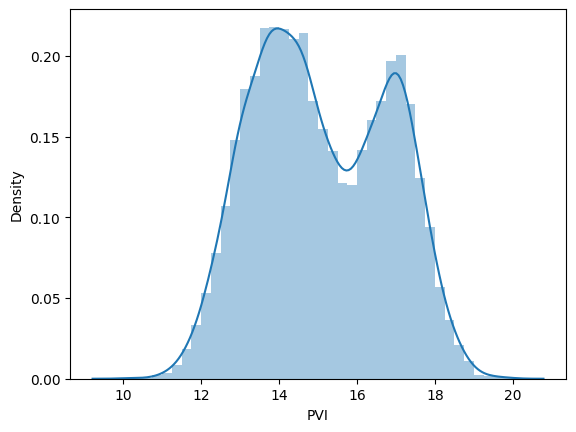

In [38]:
sns.distplot(observations["PVI"])

In [39]:
result = scipy.stats.anderson(observations["Hb level"], dist = "norm")
crit_v = result.critical_values[result.significance_level == min(result.significance_level, key = lambda sign_l: abs(sign_l - (0.05/b_value)))]
print(f"{result.statistic <= crit_v} - fail to reject/reject")


statistic, p_value = scipy.stats.kstest(observations["Hb level"], "norm")
print(f"{p_value > 0.05/b_value} - fail to reject/reject")

[False] - fail to reject/reject
False - fail to reject/reject


In [40]:
oor_amnt = sum((observations["Hb level"] > 18) | (observations["Hb level"] < 12))

print(observations["Hb level"].mean())
print(observations["Hb level"].median())
print(observations["Hb level"].var())
print(f"{oor_amnt} - values out of anticipated range")

15.148739929999401
15.199847161981658
0.6260796701654986
0 - values out of anticipated range


In [41]:
detected_outliers = detect_outliers(observations, "Hb level")
outliers_perc = (detected_outliers.sum()/observations["Hb level"].count()) * 100
print(f"{outliers_perc:.2f}%")

print(observations[~detected_outliers]["Hb level"].mean())
print(observations[~detected_outliers]["Hb level"].median())
print(observations[~detected_outliers]["Hb level"].var())


100
0.82%
15.157725577819221
15.203397154812896
0.5838308034001022


In [42]:
comp1 = replace_outliers(observations, detected_outliers, "Hb level", method = "middle_v", inplace = False)

C:\Users\misha\AppData\Local\Temp\ipykernel_17232\2143970335.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(observations["Hb level"])


<Axes: xlabel='Hb level', ylabel='Density'>

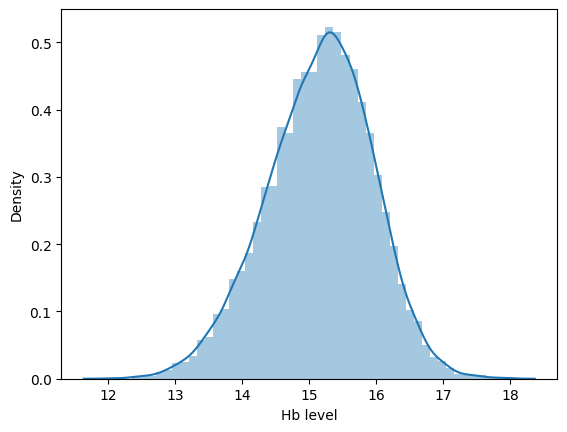

In [43]:
sns.distplot(observations["Hb level"])

In [44]:
replace_outliers(observations, detected_outliers, "Hb level", method = "median_v", inplace = True)

C:\Users\misha\AppData\Local\Temp\ipykernel_17232\1086553483.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe[column_name].mask(mask, other = df_median, inplace = True)


In [45]:
result = scipy.stats.anderson(observations["Skin Temperature"], dist = "norm")
crit_v = result.critical_values[result.significance_level == min(result.significance_level, key = lambda sign_l: abs(sign_l - (0.05/b_value)))]
print(f"{result.statistic <= crit_v} - fail to reject/reject")


statistic, p_value = scipy.stats.kstest(observations["Skin Temperature"], "norm")
print(f"{p_value > 0.05/b_value} - fail to reject/reject")

[False] - fail to reject/reject
False - fail to reject/reject


In [46]:
oor_amnt = sum((observations["Skin Temperature"] > 38) | (observations["Skin Temperature"] < 33))

print(observations["Skin Temperature"].mean())
print(observations["Skin Temperature"].median())
print(observations["Skin Temperature"].var())
print(f"{oor_amnt} - values out of anticipated range")

35.865358092548455
35.9767089639813
0.6378122016251532
0 - values out of anticipated range


In [47]:
detected_outliers = detect_outliers(observations, "Skin Temperature")
outliers_perc = (detected_outliers.sum()/observations["Skin Temperature"].count()) * 100
print(f"{outliers_perc:.2f}%")

print(observations[~detected_outliers]["Skin Temperature"].mean())
print(observations[~detected_outliers]["Skin Temperature"].median())
print(observations[~detected_outliers]["Skin Temperature"].var())


5
0.04%
35.86640959946512
35.976868085277545
0.6353792004375504


In [48]:
replace_outliers(observations, detected_outliers, "Skin Temperature", method = "median_v", inplace = True)

C:\Users\misha\AppData\Local\Temp\ipykernel_17232\1086553483.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe[column_name].mask(mask, other = df_median, inplace = True)


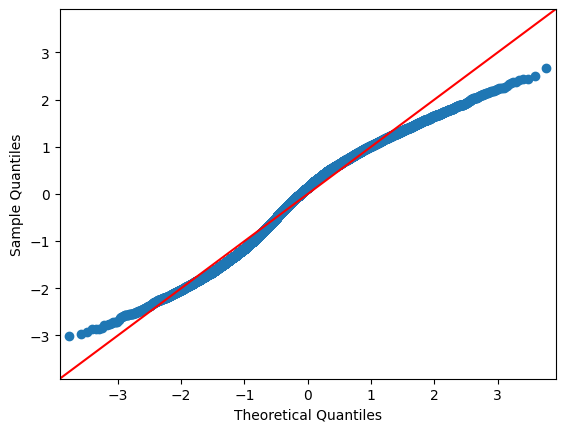

In [49]:
_ = sm.ProbPlot(observations["Skin Temperature"], fit = True).qqplot(line = "45")

In [50]:
result = scipy.stats.anderson(observations["SpO₂"], dist = "norm")
crit_v = result.critical_values[result.significance_level == min(result.significance_level, key = lambda sign_l: abs(sign_l - (0.05/b_value)))]
print(f"{result.statistic <= crit_v} - fail to reject/reject")


statistic, p_value = scipy.stats.kstest(observations["SpO₂"], "norm")
print(f"{p_value > 0.05/b_value} - fail to reject/reject")

[False] - fail to reject/reject
False - fail to reject/reject


In [51]:
oor_amnt = sum((observations["SpO₂"] > 100) | (observations["SpO₂"] < 95))

print(observations["SpO₂"].mean())
print(observations["SpO₂"].median())
print(observations["SpO₂"].var())
print(f"{oor_amnt} - values out of anticipated range")

97.33102684344969
97.34556879582168
0.48884729684797
0 - values out of anticipated range


In [52]:
detected_outliers = detect_outliers(observations, "SpO₂")
outliers_perc = (detected_outliers.sum()/observations["SpO₂"].count()) * 100
print(f"{outliers_perc:.2f}%")

print(observations[~detected_outliers]["SpO₂"].mean())
print(observations[~detected_outliers]["SpO₂"].median())
print(observations[~detected_outliers]["SpO₂"].var())


13
0.11%
97.33119100604625
97.34571978695558
0.483906245580824


In [53]:
replace_outliers(observations, detected_outliers, "SpO₂", method = "median_v", inplace = True)

C:\Users\misha\AppData\Local\Temp\ipykernel_17232\1086553483.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe[column_name].mask(mask, other = df_median, inplace = True)


C:\Users\misha\AppData\Local\Temp\ipykernel_17232\3106311098.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(observations["SpO₂"])


<Axes: xlabel='SpO₂', ylabel='Density'>

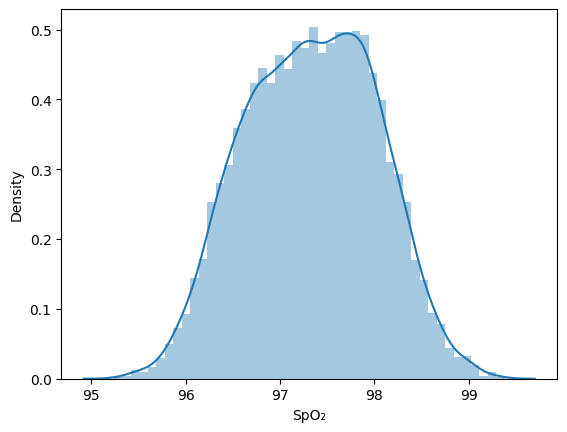

In [54]:
sns.distplot(observations["SpO₂"])

In [55]:
result = scipy.stats.anderson(observations["HR"], dist = "norm")
crit_v = result.critical_values[result.significance_level == min(result.significance_level, key = lambda sign_l: abs(sign_l - (0.05/b_value)))]
print(f"{result.statistic <= crit_v} - fail to reject/reject")

statistic, p_value = scipy.stats.kstest(observations["HR"], "norm")
print(f"{p_value > 0.05/b_value} - fail to reject/reject")


[ True] - fail to reject/reject
False - fail to reject/reject


In [56]:
oor_amnt = sum((observations["HR"] > 100) | (observations["HR"] < 60))

print(observations["HR"].mean())
print(observations["HR"].median())
print(observations["HR"].var())
print(f"{oor_amnt} - values out of anticipated range")

78.1432263210654
78.12316675714767
22.92228725256945
0 - values out of anticipated range


In [57]:
detected_outliers = detect_outliers(observations, "HR")
outliers_perc = (detected_outliers.sum()/observations["HR"].count()) * 100
print(f"{outliers_perc:.2f}%")

print(observations[~detected_outliers]["HR"].mean())
print(observations[~detected_outliers]["HR"].median())
print(observations[~detected_outliers]["HR"].var())


81
0.67%
78.13783421965735
78.1199979753683
21.663309334177743


In [58]:
comp1 = replace_outliers(observations, detected_outliers, "HR", method = "capping", inplace = False)
comp2 = replace_outliers(observations, detected_outliers, "HR", method = "median_v", inplace = False)

C:\Users\misha\AppData\Local\Temp\ipykernel_17232\2712236027.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(observations["HR"])


<Axes: xlabel='HR', ylabel='Density'>

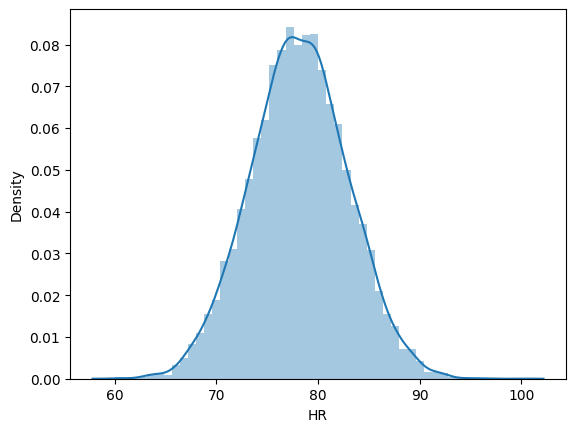

In [59]:
sns.distplot(observations["HR"])

In [60]:
replace_outliers(observations, detected_outliers, "HR", method = "capping", inplace = True)

C:\Users\misha\AppData\Local\Temp\ipykernel_17232\1086553483.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe[column_name].mask(cond_less, other = dataframe[column_name].quantile(0.05), inplace = True)
C:\Users\misha\AppData\Local\Temp\ipykernel_17232\1086553483.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which w

In [61]:
result = scipy.stats.anderson(observations["RR"], dist = "norm")
crit_v = result.critical_values[result.significance_level == min(result.significance_level, key = lambda sign_l: abs(sign_l - (0.05/b_value)))]
print(f"{result.statistic <= crit_v} - fail to reject/reject")

statistic, p_value = scipy.stats.kstest(observations["RR"], "norm")
print(f"{p_value > 0.05/b_value} - fail to reject/reject")

[False] - fail to reject/reject
False - fail to reject/reject


In [62]:
oor_amnt = sum((observations["RR"] > 20) | (observations["RR"] < 12))

print(observations["RR"].mean())
print(observations["RR"].median())
print(f"{oor_amnt} - values out of anticipated range")

16.54583400300499
16.61632880354653
0 - values out of anticipated range


In [63]:
detected_outliers = detect_outliers(observations, "RR")
outliers_perc = (detected_outliers.sum()/observations["RR"].count()) * 100
print(f"{outliers_perc:.2f}%")

print(observations[~detected_outliers]["RR"].mean())
print(observations[~detected_outliers]["RR"].median())
print(observations[~detected_outliers]["RR"].var())


8
0.07%
16.54856692372161
16.61722199738725
1.6515662953790493


In [64]:
replace_outliers(observations, detected_outliers, "RR", method = "median_v", inplace = True)

C:\Users\misha\AppData\Local\Temp\ipykernel_17232\1086553483.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe[column_name].mask(mask, other = df_median, inplace = True)


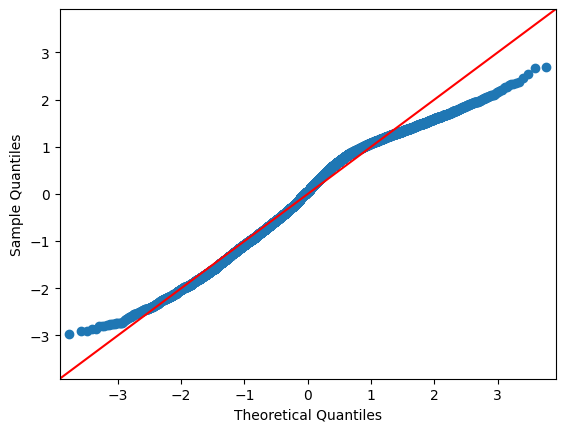

In [65]:
dgraph_ = sm.ProbPlot(observations["RR"], fit = True).qqplot(line = "45")

In [66]:
result = scipy.stats.anderson(observations["FiO₂"], dist = "norm")
crit_v = result.critical_values[result.significance_level == min(result.significance_level, key = lambda sign_l: abs(sign_l - (0.05/b_value)))]
print(f"{result.statistic <= crit_v} - fail to reject/reject")

statistic, p_value = scipy.stats.kstest(observations["FiO₂"], "norm")
print(f"{p_value > 0.05/b_value} - fail to reject/reject")


[False] - fail to reject/reject
False - fail to reject/reject


In [67]:
oor_amnt = sum((observations["FiO₂"] > 100) | (observations["FiO₂"] < 21))

print(observations["FiO₂"].mean())
print(observations["FiO₂"].median())
print(observations["FiO₂"].var())
print(f"{oor_amnt} - values out of anticipated range")

58.05792312128634
57.88400115557979
86.21221392461845
0 - values out of anticipated range


In [68]:
detected_outliers = detect_outliers(observations, "FiO₂")
outliers_perc = (detected_outliers.sum()/observations["FiO₂"].count()) * 100
print(f"{outliers_perc:.2f}%")

print(observations[~detected_outliers]["FiO₂"].mean())
print(observations[~detected_outliers]["FiO₂"].median())
print(observations[~detected_outliers]["FiO₂"].var())


183
1.51%
58.001410507717274
57.86288469315155
75.56343971464172


In [69]:
replace_outliers(observations, detected_outliers, "FiO₂", method = "median_v", inplace = True)

C:\Users\misha\AppData\Local\Temp\ipykernel_17232\1086553483.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe[column_name].mask(mask, other = df_median, inplace = True)


C:\Users\misha\AppData\Local\Temp\ipykernel_17232\3696350386.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(observations["FiO₂"])


<Axes: xlabel='FiO₂', ylabel='Density'>

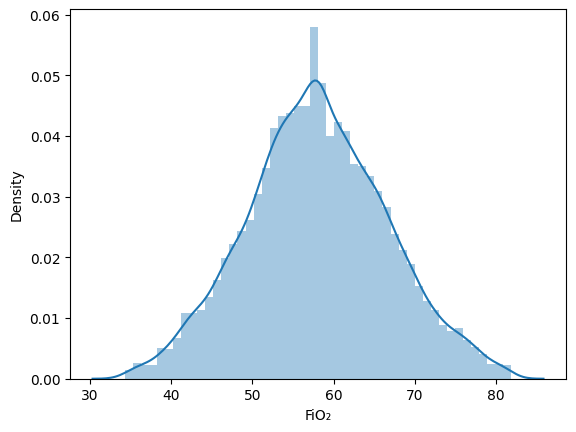

In [70]:
sns.distplot(observations["FiO₂"])


In [71]:
result = scipy.stats.anderson(observations["Blood Flow Index"], dist = "norm")
crit_v = result.critical_values[result.significance_level == min(result.significance_level, key = lambda sign_l: abs(sign_l - (0.05/b_value)))]
print(f"{result.statistic <= crit_v} - fail to reject/reject")

statistic, p_value = scipy.stats.kstest(observations["Blood Flow Index"], "norm")
print(f"{p_value > 0.05/b_value} - fail to reject/reject")

[ True] - fail to reject/reject
False - fail to reject/reject


In [72]:
detected_outliers = detect_outliers(observations, "Blood Flow Index")
outliers_perc = (detected_outliers.sum()/observations["Blood Flow Index"].count()) * 100
print(f"{outliers_perc:.2f}%")

print(observations[~detected_outliers]["Blood Flow Index"].mean())
print(observations[~detected_outliers]["Blood Flow Index"].median())
print(observations[~detected_outliers]["Blood Flow Index"].var())


80
0.66%
52.70529968033122
52.660090276145866
176.25058763086864


In [73]:
remove_outliers(observations, detected_outliers, inplace = True)


C:\Users\misha\AppData\Local\Temp\ipykernel_17232\1358749246.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(observations["Blood Flow Index"])


<Axes: xlabel='Blood Flow Index', ylabel='Density'>

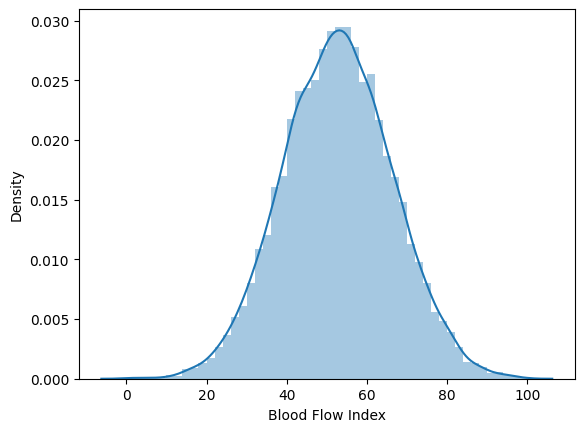

In [74]:
sns.distplot(observations["Blood Flow Index"])

In [75]:
result = scipy.stats.anderson(observations["Respiratory effort"], dist = "norm")
crit_v = result.critical_values[result.significance_level == min(result.significance_level, key = lambda sign_l: abs(sign_l - (0.05/b_value)))]
print(f"{result.statistic <= crit_v} - fail to reject/reject")

statistic, p_value = scipy.stats.kstest(observations["Respiratory effort"], "norm")
print(f"{p_value > 0.05/b_value} - fail to reject/reject")

[ True] - fail to reject/reject
False - fail to reject/reject


In [76]:
detected_outliers = detect_outliers(observations, "Respiratory effort")
outliers_perc = (detected_outliers.sum()/observations["Respiratory effort"].count()) * 100
print(f"{outliers_perc:.2f}%")

print(observations[~detected_outliers]["Respiratory effort"].mean())
print(observations[~detected_outliers]["Respiratory effort"].median())
print(observations[~detected_outliers]["Respiratory effort"].var())


105
0.87%
48.83260791628281
48.90200197709049
129.122169024656


In [77]:
remove_outliers(observations, detected_outliers, inplace = True)

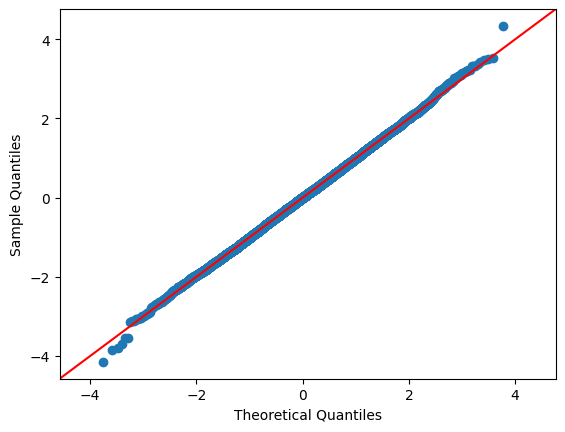

In [78]:
dgraph_ = sm.ProbPlot(observations["Respiratory effort"], fit = True).qqplot(line = "45")

In [79]:
result = scipy.stats.anderson(observations["O₂ extraction ratio"], dist = "norm")
crit_v = result.critical_values[result.significance_level == min(result.significance_level, key = lambda sign_l: abs(sign_l - (0.05/b_value)))]
print(f"{result.statistic <= crit_v} - fail to reject/reject")

statistic, p_value = scipy.stats.kstest(observations["O₂ extraction ratio"], "norm")
print(f"{p_value > 0.05/b_value} - fail to reject/reject")

[False] - fail to reject/reject
False - fail to reject/reject


In [80]:
oor_amnt = sum((observations["O₂ extraction ratio"] > 0.3) | (observations["O₂ extraction ratio"] < 0.2))

print(observations["O₂ extraction ratio"].mean())
print(observations["O₂ extraction ratio"].median())
print(f"{oor_amnt} - values out of anticipated range")

0.2495647350310721
0.2491601870882518
0 - values out of anticipated range


In [81]:
detected_outliers = detect_outliers(observations, "O₂ extraction ratio")
outliers_perc = (detected_outliers.sum()/observations["O₂ extraction ratio"].count()) * 100
print(f"{outliers_perc:.2f}%")

print(observations[~detected_outliers]["O₂ extraction ratio"].mean())
print(observations[~detected_outliers]["O₂ extraction ratio"].median())
print(observations[~detected_outliers]["O₂ extraction ratio"].var())


0
0.00%
0.2495647350310721
0.2491601870882518
0.0008362961428010623


C:\Users\misha\AppData\Local\Temp\ipykernel_17232\4222409318.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(observations["O₂ extraction ratio"])


<Axes: xlabel='O₂ extraction ratio', ylabel='Density'>

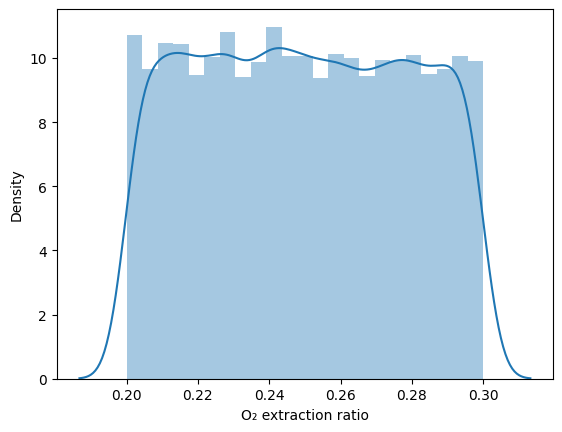

In [82]:
sns.distplot(observations["O₂ extraction ratio"])

In [83]:
result = scipy.stats.anderson(observations["BP"], dist = "norm")
crit_v = result.critical_values[result.significance_level == min(result.significance_level, key = lambda sign_l: abs(sign_l - (0.05/b_value)))]
print(f"{result.statistic <= crit_v} - fail to reject/reject")

statistic, p_value = scipy.stats.kstest(observations["BP"], "norm")
print(f"{p_value > 0.05/b_value} - fail to reject/reject")

[ True] - fail to reject/reject
False - fail to reject/reject


In [84]:
oor_amnt = sum((observations["BP"] > 120) | (observations["BP"] < 90))

print(observations["BP"].mean())
print(observations["BP"].median())
print(f"{oor_amnt} - values out of anticipated range")

104.44640470277407
104.40048723981162
0 - values out of anticipated range


In [85]:
detected_outliers = detect_outliers(observations, "BP")
outliers_perc = (detected_outliers.sum()/observations["BP"].count()) * 100
print(f"{outliers_perc:.2f}%")

print(observations[~detected_outliers]["BP"].mean())
print(observations[~detected_outliers]["BP"].median())
print(observations[~detected_outliers]["BP"].var())


63
0.52%
104.45377707705319
104.40296974956851
15.9818808168055


In [86]:
replace_outliers(observations, detected_outliers, "BP", method = "median_v", inplace = True)

C:\Users\misha\AppData\Local\Temp\ipykernel_17232\1086553483.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe[column_name].mask(mask, other = df_median, inplace = True)


C:\Users\misha\AppData\Local\Temp\ipykernel_17232\519451906.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(observations["BP"])


<Axes: xlabel='BP', ylabel='Density'>

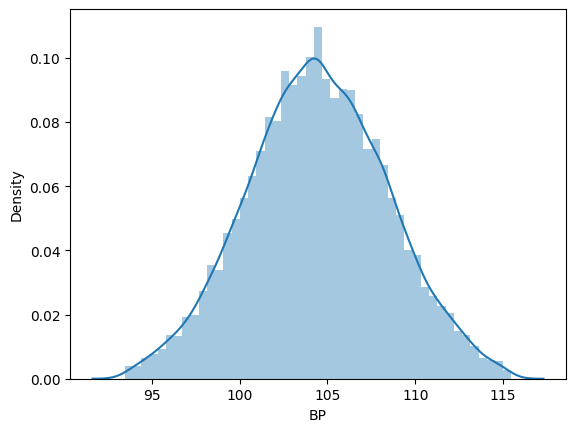

In [87]:
sns.distplot(observations["BP"])

In [88]:
result = scipy.stats.anderson(observations["longitude"], dist = "norm")
crit_v = result.critical_values[result.significance_level == min(result.significance_level, key = lambda sign_l: abs(sign_l - (0.05/b_value)))]
print(f"{result.statistic <= crit_v} - fail to reject/reject")

statistic, p_value = scipy.stats.kstest(observations["longitude"], "norm")
print(f"{p_value > 0.05/b_value} - fail to reject/reject")

[False] - fail to reject/reject
False - fail to reject/reject


In [89]:
oor_amnt = sum((observations["longitude"] > 180.00) | (observations["longitude"] < -180.00))

print(observations["longitude"].mean())
print(observations["longitude"].median())
print(f"{oor_amnt} - values out of anticipated range")

8.573028605126513
8.96317
0 - values out of anticipated range


C:\Users\misha\AppData\Local\Temp\ipykernel_17232\1479643801.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(observations["longitude"])


<Axes: xlabel='longitude', ylabel='Density'>

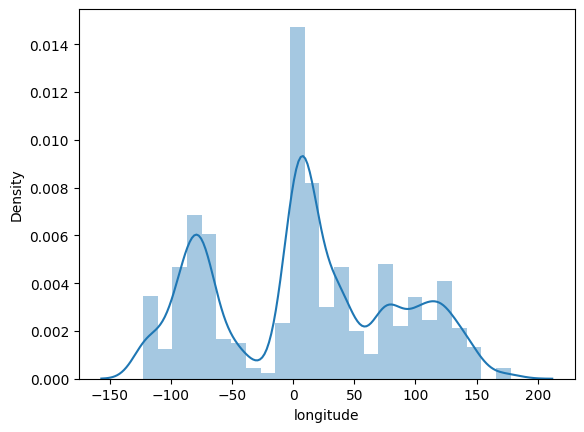

In [90]:
sns.distplot(observations["longitude"])

In [91]:
result = scipy.stats.anderson(observations["latitude"], dist = "norm")
crit_v = result.critical_values[result.significance_level == min(result.significance_level, key = lambda sign_l: abs(sign_l - (0.05/b_value)))]
print(f"{result.statistic <= crit_v} - fail to reject/reject")

statistic, p_value = scipy.stats.kstest(observations["latitude"], "norm")
print(f"{p_value > 0.05/b_value} - fail to reject/reject")

[False] - fail to reject/reject
False - fail to reject/reject


In [92]:
oor_amnt = sum((observations["latitude"] > 90.00) | (observations["latitude"] < -90.00))

print(observations["latitude"].mean())
print(observations["latitude"].median())
print(f"{oor_amnt} - values out of anticipated range")

29.970541379378556
37.19723
0 - values out of anticipated range


<Axes: ylabel='latitude'>

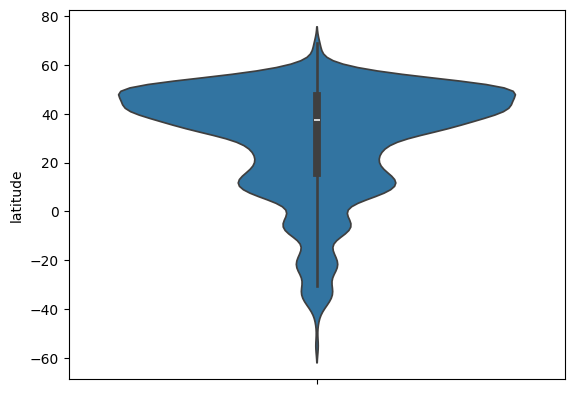

In [93]:
# dgraph_ = sm.ProbPlot(observations["latitude"], fit = True).qqplot(line = "45")
sns.violinplot(observations["latitude"])

<h4>Point-Biseliar correlation was chosen since it's used between a continuous variable and a binary variable</h4>


In [103]:
possible_attributes = [] #significant attributes
ocorr_att = [] #attributes corelating with oximetry well enough 
for k in list(observations.columns):
    if (k != "oximetry"):
        r, p = scipy.stats.pointbiserialr(observations["oximetry"], observations[k])
        if (p < 0.05/b_value):
            possible_attributes.append(k)
        if (abs(r) >= 0.4):
            ocorr_att.append(k)
        print(f"{k}: {r*100:.2f}%")
                        
print(possible_attributes)


SpO₂: 26.18%
HR: 0.75%
PI: -0.02%
RR: 64.92%
EtCO₂: 0.28%
FiO₂: 1.15%
PRV: -1.46%
BP: 0.45%
Skin Temperature: 36.95%
Motion/Activity index: -0.86%
PVI: -9.00%
Hb level: -8.79%
SV: 0.15%
CO: -0.23%
Blood Flow Index: 0.52%
PPG waveform features: 0.11%
Signal Quality Index: 1.38%
Respiratory effort: -0.46%
O₂ extraction ratio: -0.07%
SNR: -1.14%
latitude: 2.21%
longitude: 0.15%
['SpO₂', 'RR', 'Skin Temperature', 'PVI', 'Hb level']


In [104]:
pcorr_attributes = [] #partially correlated attributes that might correlate well with oximetry without impact of other, significant attributes

td_attr = list(observations.columns.drop(possible_attributes + ["oximetry"]))

for cov_var in td_attr:
    result = pg.partial_corr(data = observations, x = 'oximetry', y = cov_var, covar = possible_attributes, method='spearman')
    p = result["p-val"].values[0]
    if(p < (0.05/b_value)): #check whether the result is statistically significant with help of p-value and whether correlation is strong enough
        pcorr_attributes.append(cov_var)
        corr_coeff = result["r"].values[0]
        r_value = result["r"].values[0]
        print("%.3f for 'oximetry' and '%s'" % (corr_coeff, cov_var))
        if((abs(r_value)) >= 0.4):
            ocorr_att.append(f"{cov_var}: {r_value}")

print(set(pcorr_attributes))


set()


<h4>Thus none of the significantly correlated attributes towards oximetry interfere in correlation between oximetry and other attributes. </h4>


In [105]:
#Finally putting everything together
possible_attributes.extend(pcorr_attributes) #append partially correlated attributes

possible_attributes = list(set(possible_attributes)) #remove duplicates
ocorr_att = list(set(ocorr_att)) #remove duplicates

print(f"{possible_attributes} - attributes that might be significant")
print(f"{ocorr_att} - attributes that correlate substantially with oximetry dependent variable")


['SpO₂', 'Hb level', 'Skin Temperature', 'PVI', 'RR'] - attributes that might be significant
['RR'] - attributes that correlate substantially with oximetry dependent variable


In [106]:
pa_dict = {value: set() for value in possible_attributes} #attributes that correlate well with oximetry, for each of them found attributes that correlate well with them
for attr in possible_attributes:
    for col in list(observations.columns.drop("oximetry")):
        if (col not in possible_attributes):
            r, p = scipy.stats.spearmanr(observations[attr], observations[col])
            if(p < 0.05/b_value):
                pa_dict[attr].add(col)
print(pa_dict)


{'SpO₂': {'FiO₂'}, 'Hb level': set(), 'Skin Temperature': {'FiO₂'}, 'PVI': {'FiO₂'}, 'RR': {'FiO₂'}}



<h4>So there are no additional attributes correlate sufficiently statistically with oximetry correlated attributes</h4>

<h4>
The reason spearman correlation was chosen to test correlation between variables is the fact that some of them aren't from normal distribution. That fact is proven by previous visualization of features and normality tests
</h4>

SpO₂:
(oximetry > 0.27) (RR > 0.30) (PVI > 0.36) (Hb level > 0.20) 

HR:
(CO > 1.00) 

RR:
(oximetry > 0.65) (FiO₂ > 0.12) (Skin Temperature > 0.33) 

Skin Temperature:
(oximetry > 0.41) 

SpO₂:
(FiO₂ > -0.14) 

Skin Temperature:
(PVI > -0.44) 



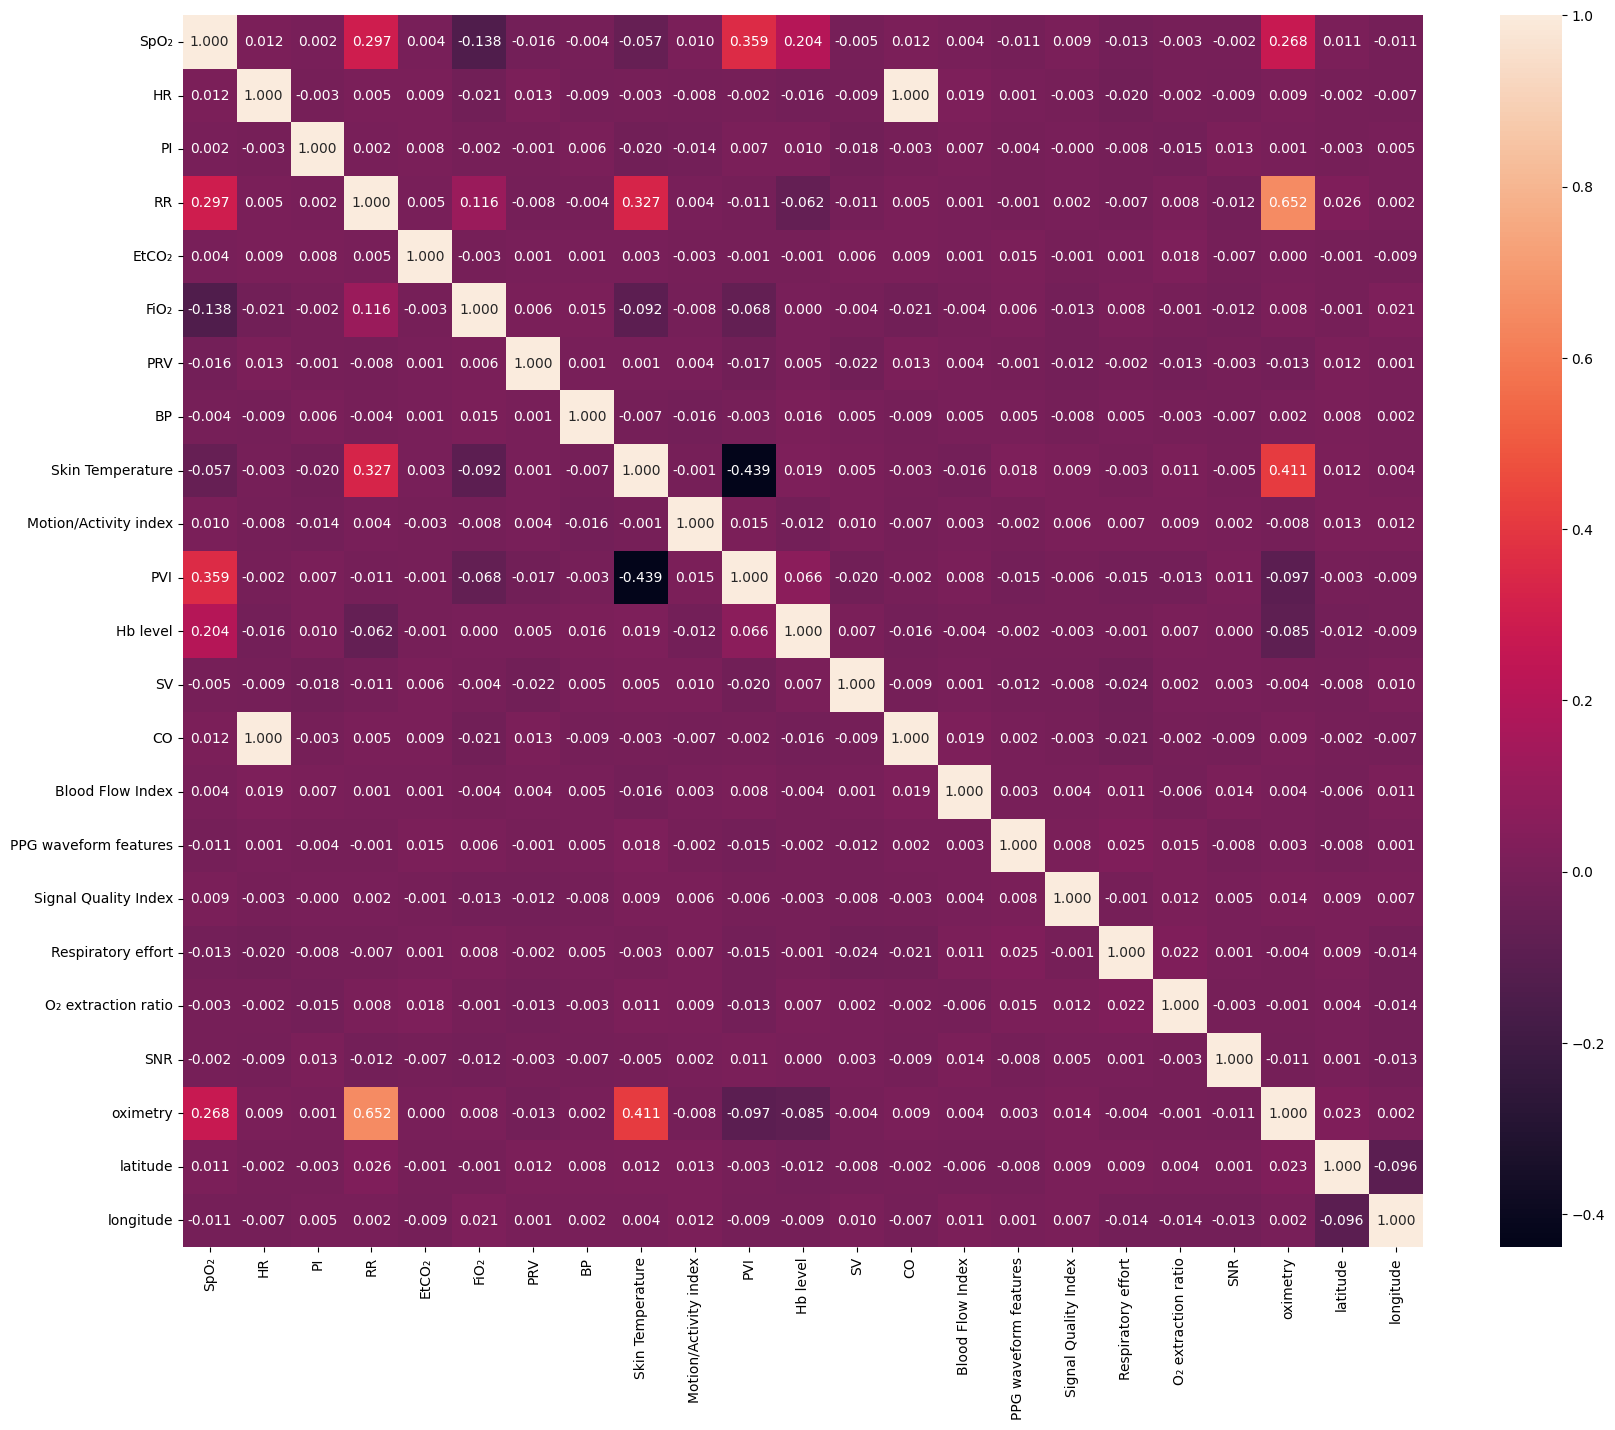

In [107]:
correlation_matrix = observations.corr(method = "spearman", numeric_only = True)
fig, ax = plt.subplots(figsize=(20,16))
sns.heatmap(correlation_matrix, ax=ax, annot=True, fmt = '.3f')

pos_corr = {} #attributes that correlate positively with each other
neg_corr = {} #attributes that correlate negatively with each other

u_dict = None

for i in range(0, 22):
    for k in range(i + 1, 23):
        corr_coeff = correlation_matrix.iat[i, k]
        if(abs(corr_coeff) >= 0.1):
            cell = np.where(correlation_matrix == correlation_matrix.iat[i, k])
            row_name = list(observations.columns)[cell[0][0]]
            col_name = list(observations.columns)[cell[1][0]]
            if(corr_coeff > 0):
                u_dict = pos_corr
            else:
                u_dict = neg_corr
            if(u_dict.get(row_name) == None):
                u_dict[row_name] = {"%s > %.2f" % (col_name, corr_coeff)} 
            else:
                u_dict[row_name].add("%s > %.2f" % (col_name, corr_coeff))

for k in pos_corr.keys():
    cv = list(pos_corr[k])
    print(f"{k}:")
    for p in range(len(cv)):
        print(f"({cv[p]})", end = " ")
    print("\n")

for k in neg_corr.keys():
    cv = list(neg_corr[k])
    print(f"{k}:")
    for p in range(len(cv)):
        print(f"({cv[p]})", end = " ")
    print("\n")



<h4>
Eventually we aren't able to merge other datasets with <b>observations</b> dataset due to lack of data in them as well as lack of information about them.
</h4>

# Data cleaning and integration

In [ ]:
dup_observ = observations.duplicated(keep = "first")
print(dup_observ.any().sum())
observations.drop_duplicates(inplace = True)


0


In [131]:
observations.shape

(12132, 23)

In [ ]:
SPO2_limit = observations["SpO₂"].min() + (observations["SpO₂"].max() - observations["SpO₂"].min())* 0.1 #maximum 10% limit
FIO2_limit = observations["FiO₂"].max() - (observations["FiO₂"].max() - observations["FiO₂"].min())* 0.1 #maximum 10% limit
CO_limit = observations["CO"].min() + (observations["CO"].max() - observations["CO"].min())* 0.05 #maximum 5% limit
SV_limit = observations["SV"].max() - (observations["SV"].max() - observations["SV"].min())* 0.05 #maximum 5% limit


print(len(list(observations[(observations["SpO₂"] < SPO2_limit) & (observations['FiO₂'] > FIO2_limit)].index)))  # abnormal SpO2 vs FiO2
print(len(list(observations[(observations['SV'] > SV_limit) & (observations['CO'] < CO_limit)])))        # inconsistent SV vs CO
print(len(list(observations[(observations['Respiratory effort'] > 90) & (observations['Blood Flow Index'] < 10)]))) #inconsistency between Respiratory effort and Bloodflow index

0
23
23
